<a href="https://colab.research.google.com/github/kuzovkov/neural-university/blob/main/%D0%94%D0%97_Ultra_Pro_%D0%92%D0%B0%D1%80%D0%B8%D0%B0%D1%86%D0%B8%D0%BE%D0%BD%D0%BD%D1%8B%D0%B5_%D0%B0%D0%B2%D1%82%D0%BE%D0%BA%D0%BE%D0%B4%D0%B8%D1%80%D0%BE%D0%B2%D1%89%D0%B8%D0%BA%D0%B8_%7C_%D0%A3%D0%98%D0%98.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Давайте немного отвлечемся от тяжелых будней будущего нейронщика и вспомним, что в мире есть маленькие радости - а именно мультяшки.

В этой работе:
- скачайте датасет от Гугла с мультяшными персонажами. Ссылка: https://storage.yandexcloud.net/aiueducation/Content/advanced/l1/cartoonset10k.zip
- обучите VAE на данном датасете
- посмотрите качество воспроизведения мультяшек
- нагенерите любое колличество мультяшек на свой вкус
- оцените работу декодера

In [1]:
# Импортируем TensorFlow
import tensorflow as tf
# Импортируем Keras
import keras
# Подключим Numpy
import numpy as np

# Подключим библиотеку отображения графиков
import matplotlib.pyplot as plt

# Подключим датасет рукописных цифр MNIST
from tensorflow.keras.datasets import mnist

# Импортируем Keras
from tensorflow import keras

# Подключим все необходимые слои Keras
from tensorflow.keras.layers import Dense, Flatten, Reshape, Input, Lambda, LeakyReLU
from tensorflow.keras.layers import BatchNormalization, Dropout, concatenate, Conv2D, Conv2DTranspose

# Подключим модуль вычислений на Keras
import keras.backend as K

# Подключим модуль работы с операционной системой
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # От tensorflow будет получать только ошибки

In [2]:
!wget https://storage.yandexcloud.net/aiueducation/Content/advanced/l1/cartoonset10k.zip

--2025-10-21 15:49:44--  https://storage.yandexcloud.net/aiueducation/Content/advanced/l1/cartoonset10k.zip
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 478562192 (456M) [application/x-zip-compressed]
Saving to: ‘cartoonset10k.zip’

cartoonset10k.zip   100%[===================>] 456.39M  23.7MB/s    in 21s     

2025-10-21 15:50:06 (22.2 MB/s) - ‘cartoonset10k.zip’ saved [478562192/478562192]



In [3]:
!unzip -q cartoonset10k.zip
!mkdir cartoonset
!mv *.csv cartoonset/
!mv *.png cartoonset/

всего картинок: 10000
размер: 500x500


array([['eye_lashes', 0, 2],
       ['eye_lid', 0, 2],
       ['chin_length', 0, 3],
       ['eyebrow_weight', 0, 2],
       ['eyebrow_shape', 3, 14],
       ['eyebrow_thickness', 3, 4],
       ['face_shape', 6, 7],
       ['facial_hair', 14, 15],
       ['hair', 73, 111],
       ['eye_color', 2, 5],
       ['face_color', 2, 11],
       ['hair_color', 2, 10],
       ['glasses', 11, 12],
       ['glasses_color', 5, 7],
       ['eye_slant', 2, 3],
       ['eyebrow_width', 0, 3],
       ['eye_eyebrow_distance', 1, 3]], dtype=object)

array([['eye_lashes', 1, 2],
       ['eye_lid', 0, 2],
       ['chin_length', 1, 3],
       ['eyebrow_weight', 1, 2],
       ['eyebrow_shape', 8, 14],
       ['eyebrow_thickness', 0, 4],
       ['face_shape', 2, 7],
       ['facial_hair', 14, 15],
       ['hair', 95, 111],
       ['eye_color', 1, 5],
       ['face_color', 3, 11],
       ['hair_color', 3, 10],
       ['glasses', 9, 12],
       ['glasses_color', 2, 7],
       ['eye_slant', 0, 3],
       ['eyebrow_width', 2, 3],
       ['eye_eyebrow_distance', 0, 3]], dtype=object)

array([['eye_lashes', 1, 2],
       ['eye_lid', 1, 2],
       ['chin_length', 1, 3],
       ['eyebrow_weight', 0, 2],
       ['eyebrow_shape', 7, 14],
       ['eyebrow_thickness', 2, 4],
       ['face_shape', 3, 7],
       ['facial_hair', 2, 15],
       ['hair', 66, 111],
       ['eye_color', 0, 5],
       ['face_color', 1, 11],
       ['hair_color', 8, 10],
       ['glasses', 10, 12],
       ['glasses_color', 3, 7],
       ['eye_slant', 2, 3],
       ['eyebrow_width', 1, 3],
       ['eye_eyebrow_distance', 0, 3]], dtype=object)

array([['eye_lashes', 1, 2],
       ['eye_lid', 0, 2],
       ['chin_length', 2, 3],
       ['eyebrow_weight', 1, 2],
       ['eyebrow_shape', 12, 14],
       ['eyebrow_thickness', 0, 4],
       ['face_shape', 0, 7],
       ['facial_hair', 4, 15],
       ['hair', 55, 111],
       ['eye_color', 0, 5],
       ['face_color', 3, 11],
       ['hair_color', 3, 10],
       ['glasses', 11, 12],
       ['glasses_color', 2, 7],
       ['eye_slant', 1, 3],
       ['eyebrow_width', 0, 3],
       ['eye_eyebrow_distance', 0, 3]], dtype=object)

...

array([['eye_lashes', 0, 2],
       ['eye_lid', 0, 2],
       ['chin_length', 0, 3],
       ['eyebrow_weight', 0, 2],
       ['eyebrow_shape', 13, 14],
       ['eyebrow_thickness', 0, 4],
       ['face_shape', 2, 7],
       ['facial_hair', 14, 15],
       ['hair', 82, 111],
       ['eye_color', 3, 5],
       ['face_color', 5, 11],
       ['hair_color', 9, 10],
       ['glasses', 11, 12],
       ['glasses_color', 6, 7],
       ['eye_slant', 0, 3],
       ['eyebrow_width', 2, 3],
       ['eye_eyebrow_distance', 1, 3]], dtype=object)

array([['eye_lashes', 1, 2],
       ['eye_lid', 0, 2],
       ['chin_length', 1, 3],
       ['eyebrow_weight', 0, 2],
       ['eyebrow_shape', 13, 14],
       ['eyebrow_thickness', 3, 4],
       ['face_shape', 3, 7],
       ['facial_hair', 3, 15],
       ['hair', 50, 111],
       ['eye_color', 4, 5],
       ['face_color', 10, 11],
       ['hair_color', 9, 10],
       ['glasses', 11, 12],
       ['glasses_color', 6, 7],
       ['eye_slant', 1, 3],
       ['eyebrow_width', 2, 3],
       ['eye_eyebrow_distance', 0, 3]], dtype=object)

array([['eye_lashes', 1, 2],
       ['eye_lid', 0, 2],
       ['chin_length', 0, 3],
       ['eyebrow_weight', 1, 2],
       ['eyebrow_shape', 12, 14],
       ['eyebrow_thickness', 0, 4],
       ['face_shape', 6, 7],
       ['facial_hair', 9, 15],
       ['hair', 80, 111],
       ['eye_color', 0, 5],
       ['face_color', 10, 11],
       ['hair_color', 0, 10],
       ['glasses', 0, 12],
       ['glasses_color', 1, 7],
       ['eye_slant', 1, 3],
       ['eyebrow_width', 1, 3],
       ['eye_eyebrow_distance', 1, 3]], dtype=object)

array([['eye_lashes', 1, 2],
       ['eye_lid', 0, 2],
       ['chin_length', 0, 3],
       ['eyebrow_weight', 0, 2],
       ['eyebrow_shape', 3, 14],
       ['eyebrow_thickness', 3, 4],
       ['face_shape', 3, 7],
       ['facial_hair', 14, 15],
       ['hair', 58, 111],
       ['eye_color', 3, 5],
       ['face_color', 10, 11],
       ['hair_color', 6, 10],
       ['glasses', 11, 12],
       ['glasses_color', 3, 7],
       ['eye_slant', 2, 3],
       ['eyebrow_width', 1, 3],
       ['eye_eyebrow_distance', 0, 3]], dtype=object)

array([['eye_lashes', 0, 2],
       ['eye_lid', 1, 2],
       ['chin_length', 1, 3],
       ['eyebrow_weight', 0, 2],
       ['eyebrow_shape', 5, 14],
       ['eyebrow_thickness', 3, 4],
       ['face_shape', 4, 7],
       ['facial_hair', 3, 15],
       ['hair', 99, 111],
       ['eye_color', 1, 5],
       ['face_color', 6, 11],
       ['hair_color', 7, 10],
       ['glasses', 11, 12],
       ['glasses_color', 2, 7],
       ['eye_slant', 2, 3],
       ['eyebrow_width', 2, 3],
       ['eye_eyebrow_distance', 2, 3]], dtype=object)

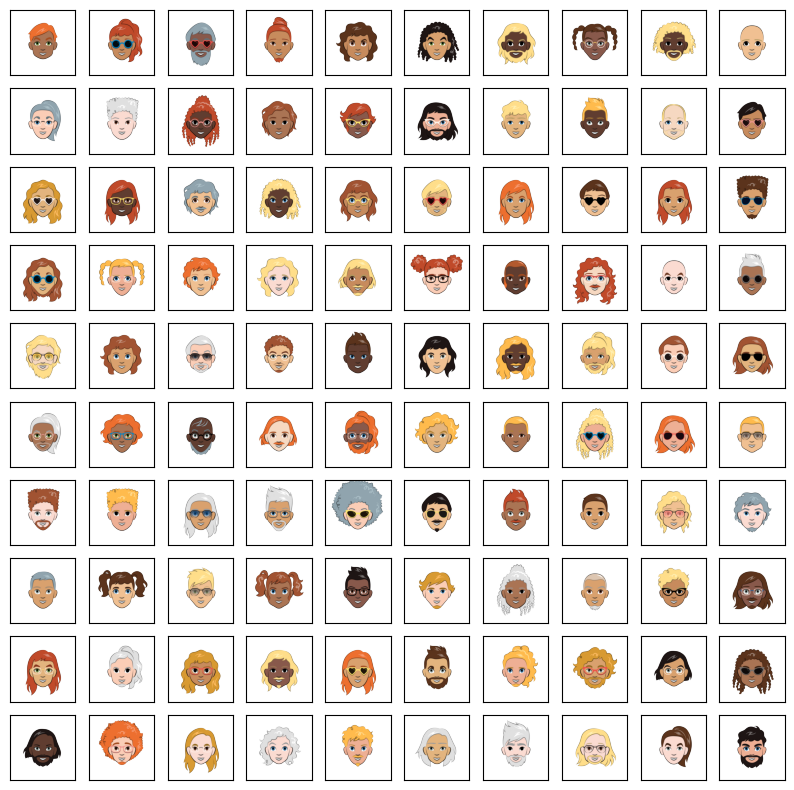

In [4]:
#посмотрим на данные
import pandas as pd
from PIL import Image
import matplotlib.image as mpimg

files_dir='cartoonset'
files_list_png = list(filter(lambda i: i[-3:] == 'png', os.listdir(files_dir)))
print(f'всего картинок: {len(files_list_png)}')
plt.figure(figsize=(10, 10))
num=1
for filename_png in files_list_png[:100]:
    filename_png_path = f'{files_dir}/{filename_png}'
    ax = plt.subplot(10, 10, num)
    image = Image.open(filename_png_path)
    if num == 1:
        print(f'размер: {image.size[0]}x{image.size[1]}')
    plt.imshow(image)
    ax.get_xaxis().set_visible(False)                             # Спрячем ось X
    ax.get_yaxis().set_visible(False)                              # Спрячем ось Y
    num += 1

for filename_png in files_list_png[:100]:
    filename_png_path = f'{files_dir}/{filename_png}'
    filename_csv_path = f'{filename_png_path[:-3]}csv'
    df = pd.read_csv(filename_csv_path)
    display(df.values)

In [5]:
# --- Параметры ---
files_dir = "cartoonset"
image_shape = (500, 500, 4)
latent_dim = 64   # Размер латентного пространства
batch_size = 8
epochs = 20

In [6]:

# --- Чтение изображений ---
x_train = []
files_list_png = [f for f in os.listdir(files_dir) if f.endswith('.png')]
for filename_png in files_list_png[:100]:  # ограничимся первыми 100 изображениями
    filename_png_path = os.path.join(files_dir, filename_png)
    np_image = mpimg.imread(filename_png_path).astype('float32')
    x_train.append(np_image)

x_train = np.array(x_train)
print("Данные:", x_train.shape)

Данные: (100, 500, 500, 4)


In [7]:
# --- Определение вспомогательных функций ---
def sampling(args):
    """Сэмплинг из распределения (z_mean, z_log_var)."""
    z_mean, z_log_var = args
    epsilon = tf.random.normal(shape=tf.shape(z_mean))
    return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [8]:
# --- Энкодер ---

from tensorflow.keras import layers

encoder_inputs = keras.Input(shape=image_shape)

x = layers.Conv2D(32, 3, strides=2, padding="same", activation="relu")(encoder_inputs)
x = layers.Conv2D(64, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Conv2D(128, 3, strides=2, padding="same", activation="relu")(x)
x = layers.Flatten()(x)
x = layers.Dense(256, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = layers.Lambda(sampling, output_shape=(latent_dim,), name="z")([z_mean, z_log_var])

encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 500, 500,  │          0 │ -                 │
│ (InputLayer)        │ 4)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 250, 250,  │      1,184 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 125, 125,  │     18,496 │ conv2d[0][0]      │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 63, 63,    │     73,856 │ conv2d_1[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 508032)    │          0 │ conv2d_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │ 130,056,4… │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_mean (Dense)      │ (None, 64)        │     16,448 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z_log_var (Dense)   │ (None, 64)        │     16,448 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ z (Lambda)          │ (None, 64)        │          0 │ z_mean[0][0],     │
│                     │                   │            │ z_log_var[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 130,182,880 (496.61 MB)

 Trainable params: 130,182,880 (496.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# --- Декодер
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(63 * 63 * 128, activation="relu")(latent_inputs)
x = layers.Reshape((63, 63, 128))(x)
x = layers.Conv2DTranspose(128, 3, strides=2, padding="same", activation="relu")(x)  # 63→126
x = layers.Conv2DTranspose(64, 3, strides=2, padding="same", activation="relu")(x)   # 126→252
x = layers.Conv2DTranspose(32, 4, strides=2, padding="valid", activation="relu")(x)  # 252→(252-1)*2+4=506
x = layers.Cropping2D(((3, 3), (3, 3)))(x)                                           # 506→500
decoder_outputs = layers.Conv2DTranspose(4, 3, activation="sigmoid", padding="same")(x)


decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 508032)         │    33,022,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 63, 63, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 126, 126, 128)  │       147,584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 252, 252, 64)   │        73,792 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_2              │ (None, 506, 506, 32)   │        32,800 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cropping2d (Cropping2D)         │ (None, 500, 500, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_3              │ (None, 500, 500, 4)    │         1,156 │
│ (Conv2DTranspose)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,277,412 (126.94 MB)

 Trainable params: 33,277,412 (126.94 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:

# --- Модель вариационного автокодировщика ---
z_mean, z_log_var, z = encoder(encoder_inputs)
reconstructed = decoder(z)
vae = keras.Model(encoder_inputs, reconstructed, name="vae")

In [11]:
# --- Класс вариационного автокодировщика ---
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super(VAE, self).__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder

    def train_step(self, data):
        if isinstance(data, tuple):
            data = data[0]

        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.backend.binary_crossentropy(data, reconstruction),
                    axis=(1, 2, 3)
                )
            )
            kl_loss = -0.5 * tf.reduce_mean(
                tf.reduce_sum(1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var), axis=1)
            )
            total_loss = reconstruction_loss + kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))

        return {
            "loss": total_loss,
            "reconstruction_loss": reconstruction_loss,
            "kl_loss": kl_loss
        }


In [12]:
vae = VAE(encoder, decoder)

In [13]:
vae.compile(optimizer=keras.optimizers.Adam())

In [14]:
# --- Обучение ---
vae.fit(x_train, epochs=epochs, batch_size=batch_size)

Epoch 1/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - kl_loss: 15648473088.0000 - loss: 15649132544.0000 - reconstruction_loss: 659493.1875
Epoch 2/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - kl_loss: 450.4254 - loss: 257493.6562 - reconstruction_loss: 257043.2188
Epoch 3/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - kl_loss: 157.6173 - loss: 233935.7188 - reconstruction_loss: 233778.0938
Epoch 4/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 151ms/step - kl_loss: 117.6038 - loss: 224349.3750 - reconstruction_loss: 224231.7656
Epoch 5/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - kl_loss: 179.7260 - loss: 213010.1875 - reconstruction_loss: 212830.4688
Epoch 6/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - kl_loss: 273.2846 - loss: 204022.5156 - reconstruction_loss: 203749.2344
Epoch 7/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 146ms/step - kl_loss: 369.8339 - loss: 201596.1094 - reconstruction_loss: 201226.2812
Epoch 8/20
13/13 ━━━━━━━━━━━━━━━━━━━━ 2s 145ms/step - kl_loss: 390.2973 - loss: 197320.6094 - recons

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


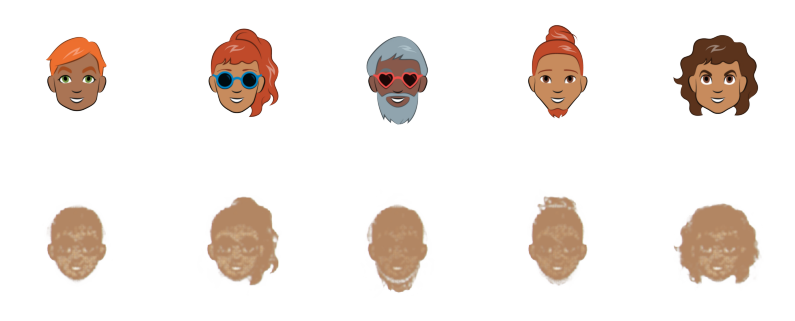

In [15]:
# --- Тест: визуализация ---
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    img = x_train[i]
    z_mean_val, _, _ = encoder.predict(np.expand_dims(img, axis=0))
    reconstructed_img = decoder.predict(z_mean_val)
    plt.subplot(2, n, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructed_img[0])
    plt.axis("off")
plt.show()

In [16]:
#генератор

from tensorflow.keras.utils import Sequence

class CartoonDataGenerator(Sequence):
    def __init__(self, files_dir, batch_size=8, img_shape=(500, 500, 4), shuffle=True):
        self.files_dir = files_dir
        self.batch_size = batch_size
        self.img_shape = img_shape
        self.shuffle = shuffle
        self.files = [os.path.join(files_dir, f) for f in os.listdir(files_dir) if f.endswith(".png")]
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.files) / self.batch_size))

    def __getitem__(self, idx):
        batch_files = self.files[idx * self.batch_size:(idx + 1) * self.batch_size]
        batch_images = [self.load_image(f) for f in batch_files]
        return np.array(batch_images, dtype="float32")

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.files)

    def load_image(self, path):
        np_image = mpimg.imread(path).astype("float32")
        # гарантируем, что размер совпадает
        if np_image.shape != self.img_shape:
            np_image = tf.image.resize(np_image, self.img_shape[:2]).numpy()
        return np_image

In [17]:
train_gen = CartoonDataGenerator(files_dir, batch_size=batch_size, img_shape=(500, 500, 4))

In [18]:
vae.fit(
    train_gen,
    epochs=epochs,
    verbose=1
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1250/1250 ━━━━━━━━━━━━━━━━━━━━ 197s 153ms/step - kl_loss: 377.0292 - loss: 112106.2891 - reconstruction_loss: 111729.2656
Epoch 2/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 190s 152ms/step - kl_loss: 305.1737 - loss: 100655.5859 - reconstruction_loss: 100350.4141
Epoch 3/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 190s 152ms/step - kl_loss: 275.8957 - loss: 97162.6875 - reconstruction_loss: 96886.7891
Epoch 4/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 190s 152ms/step - kl_loss: 253.7014 - loss: 95350.2734 - reconstruction_loss: 95096.5703
Epoch 5/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 190s 152ms/step - kl_loss: 240.4518 - loss: 94530.7734 - reconstruction_loss: 94290.3203
Epoch 6/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 190s 152ms/step - kl_loss: 246.4729 - loss: 95590.7578 - reconstruction_loss: 95344.2891
Epoch 7/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 187s 150ms/step - kl_loss: 260.1174 - loss: 94035.9922 - reconstruction_loss: 93775.8750
Epoch 8/20
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 187s 150ms/step - kl_loss: 226.0266 - loss: 9261

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


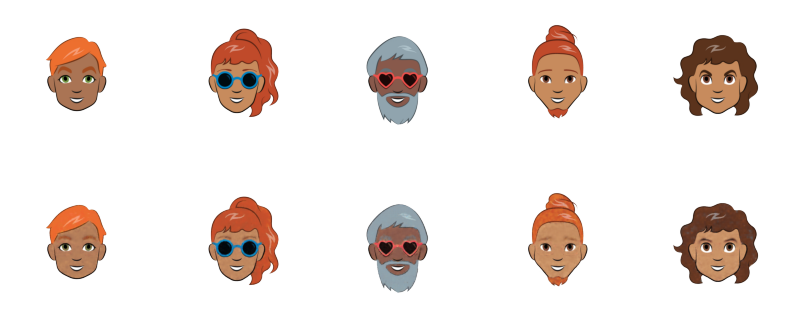

In [ ]:
# --- Тест: визуализация ---
n = 5
plt.figure(figsize=(10, 4))
for i in range(n):
    img = x_train[i]
    z_mean_val, _, _ = encoder.predict(np.expand_dims(img, axis=0))
    reconstructed_img = decoder.predict(z_mean_val)
    plt.subplot(2, n, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.subplot(2, n, n + i + 1)
    plt.imshow(reconstructed_img[0])
    plt.axis("off")
plt.show()

In [19]:
import matplotlib.pyplot as plt

def generate_images(decoder, latent_dim=64, n=10, figsize=(15, 3)):
    """
    Генерирует n изображений из случайных точек латентного пространства.

    decoder — обученный декодер
    latent_dim — размерность скрытого пространства
    n — количество изображений
    figsize — размер итогового графика
    """
    # Сэмплируем случайные вектора z из стандартного нормального распределения
    z_samples = np.random.normal(size=(n, latent_dim)).astype("float32")

    # Получаем изображения
    generated = decoder.predict(z_samples)

    # Визуализируем
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(generated[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

    return generated


1/1 ━━━━━━━━━━━━━━━━━━━━ 10s 10s/step


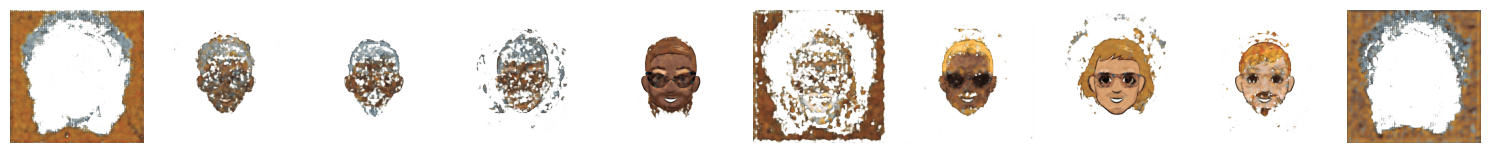

array([[[[4.65468705e-01, 3.93947959e-01, 3.07107687e-01,
          9.45396185e-01],
         [3.66892189e-01, 2.99744070e-01, 1.98654145e-01,
          9.89751935e-01],
         [3.66982132e-01, 3.17633420e-01, 2.40121335e-01,
          9.84806895e-01],
         ...,
         [4.92208034e-01, 4.11485106e-01, 2.91262090e-01,
          9.74136293e-01],
         [4.65274453e-01, 3.86330605e-01, 2.96784043e-01,
          9.87021387e-01],
         [4.95479941e-01, 4.31452960e-01, 3.56749028e-01,
          9.63968813e-01]],

        [[4.22631502e-01, 3.27569902e-01, 2.26324677e-01,
          9.84227002e-01],
         [3.64421278e-01, 2.51675069e-01, 1.49396360e-01,
          9.98395264e-01],
         [4.29504067e-01, 3.33757520e-01, 2.10291505e-01,
          9.97324824e-01],
         ...,
         [5.86416543e-01, 4.37292039e-01, 2.86363184e-01,
          9.98218954e-01],
         [5.68559468e-01, 3.98786157e-01, 2.72306263e-01,
          9.99580085e-01],
         [5.83578587e-01, 4.5274901

In [20]:
# После обучения VAE
generate_images(decoder, latent_dim=64, n=10)

In [21]:
vae.save('dz-vae.keras')

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


In [22]:
 from google.colab import files

 files.download('dz-vae.keras')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>